In [ ]:
import os, random, shutil, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageEnhance, ImageFilter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

import pytesseract
pytesseract.pytesseract.tesseract_cmd = r'C:\Users\DPQUAI250141\AppData\Local\Programs\Tesseract-OCR\tesseract.exe'
os.environ['TESSDATA_PREFIX'] = r'C:\Users\DPQUAI250141\AppData\Local\Programs\Tesseract-OCR\tessdata'

# ── Config ────────────────────────────────────────────────────────
SEED           = 42
NUM_CLASSES    = 10
IMG_SIZE       = 224
BATCH_SIZE     = 16
NUM_EPOCHS     = 10
LR             = 1e-3
UNFREEZE_EPOCH = 3
DEVICE         = torch.device('cpu')
DATA_ROOT      = r'C:\Users\DPQUAI250141\Downloads\rvlcdip_sample\rvlcdip_sample'
CLASSES        = ['ADVE', 'Email', 'Form', 'Letter', 'Memo',
                  'News', 'Note', 'Report', 'Resume', 'Scientific']

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("✅ All imports successful!")
print(f"   PyTorch    : {torch.__version__}")
print(f"   Tesseract  : {pytesseract.get_tesseract_version()}")
print(f"   Device     : {DEVICE}")
print(f"   Classes    : {NUM_CLASSES}")
print(f"   Epochs     : {NUM_EPOCHS}")
print(f"   Data root  : {DATA_ROOT}")

✅ All imports successful!
   PyTorch    : 2.11.0+cpu
   Tesseract  : 5.5.0.20241111
   Device     : cpu
   Classes    : 10
   Epochs     : 10
   Data root  : C:\Users\DPQUAI250141\Downloads\rvlcdip_sample\rvlcdip_sample


In [ ]:
def create_splits(root, classes, n_per_class=500,
                  train_r=0.70, val_r=0.15, seed=42):
    random.seed(seed)
    splits = {'train': [], 'val': [], 'test': []}

    for cls in classes:
        cls_dir = os.path.join(root, 'all', cls)
        imgs = sorted([
            os.path.join(cls_dir, f)
            for f in os.listdir(cls_dir)
            if f.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))
        ])
        random.shuffle(imgs)
        imgs  = imgs[:n_per_class]
        n     = len(imgs)
        n_tr  = int(n * train_r)
        n_val = int(n * val_r)

        splits['train'].extend([(p, cls) for p in imgs[:n_tr]])
        splits['val'  ].extend([(p, cls) for p in imgs[n_tr:n_tr+n_val]])
        splits['test' ].extend([(p, cls) for p in imgs[n_tr+n_val:]])

    for split_name, items in splits.items():
        for img_path, cls in items:
            dst_dir = os.path.join(root, split_name, cls)
            os.makedirs(dst_dir, exist_ok=True)
            dst = os.path.join(dst_dir, os.path.basename(img_path))
            if not os.path.exists(dst):
                shutil.copy2(img_path, dst)

    print("📊 Split Summary")
    print(f"{'Split':<10} {'Images':>8} {'Per Class':>12}")
    print("-" * 32)
    for s, items in splits.items():
        print(f"{s:<10} {len(items):>8} {len(items)//len(classes):>12}")
    print("-" * 32)
    print(f"{'Total':<10} {sum(len(v) for v in splits.values()):>8}")
    return splits

all_splits = create_splits(DATA_ROOT, CLASSES)

📊 Split Summary
Split        Images    Per Class
--------------------------------
train          3500          350
val             750           75
test            750           75
--------------------------------
Total          5000


In [ ]:
def detect_rotation(img_path):
    """Detect skew angle using minAreaRect on text pixels."""
    try:
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.array(Image.open(img_path).convert('L'))
        _, thresh = cv2.threshold(img, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        coords = np.column_stack(np.where(thresh > 0))
        if len(coords) < 100:
            return 0.0, 'empty'
        angle = cv2.minAreaRect(coords)[-1]
        if angle < -45:
            angle = 90 + angle
        return round(angle, 2), 'ok'
    except:
        return 0.0, 'error'

def check_empty(img_path, threshold=0.98):
    """Check if image is mostly white (>98% white pixels)."""
    try:
        img = np.array(Image.open(img_path).convert('L'))
        white_ratio = (img > 240).sum() / img.size
        return white_ratio > threshold, round(white_ratio * 100, 1)
    except:
        return True, 100.0

# ── Scan train split ──────────────────────────────────────────────
print("🔍 Scanning train images for quality issues...\n")
print(f"{'Class':<14} {'Total':>6} {'Empty':>7} {'Rotated':>9} {'Avg°':>8}")
print("─" * 50)

rotation_report = {}
empty_report    = {}
all_angles      = []

for cls in CLASSES:
    cls_dir   = os.path.join(DATA_ROOT, 'train', cls)
    files     = sorted(os.listdir(cls_dir))
    n_empty   = 0
    n_rotated = 0
    angles    = []

    for fname in files:
        path = os.path.join(cls_dir, fname)
        is_empty, _    = check_empty(path)
        angle, status  = detect_rotation(path)
        if is_empty:
            n_empty += 1
        if status == 'ok':
            angles.append(abs(angle))
            if abs(angle) > 5:
                n_rotated += 1

    avg_angle = np.mean(angles) if angles else 0
    all_angles.extend(angles)
    rotation_report[cls] = {'total'    : len(files),
                             'rotated'  : n_rotated,
                             'avg_angle': avg_angle}
    empty_report[cls] = n_empty

    ef = '⚠️' if n_empty   > 10 else '✅'
    rf = '⚠️' if n_rotated > 10 else '✅'
    print(f"  {cls:<12} {len(files):>6} "
          f" {ef}{n_empty:>3} "
          f"  {rf}{n_rotated:>4} "
          f" {avg_angle:>7.1f}°")

print("─" * 50)
print(f"  {'TOTAL':<12}"
      f" {sum(r['total']   for r in rotation_report.values()):>6}"
      f"  {sum(empty_report.values()):>6}"
      f"  {sum(r['rotated'] for r in rotation_report.values()):>7}")

🔍 Scanning train images for quality issues...

Class           Total   Empty   Rotated     Avg°
──────────────────────────────────────────────────
  ADVE            350  ✅  7   ✅   8      0.7°
  Email           350  ⚠️153   ⚠️  31      2.8°
  Form            350  ✅  8   ⚠️  18      1.4°
  Letter          350  ✅  4   ⚠️  14      0.9°
  Memo            350  ✅  6   ⚠️  22      1.5°
  News            350  ✅  1   ⚠️  19      1.7°
  Note            350  ✅  2   ✅   0      0.0°
  Report          350  ⚠️ 23   ⚠️  30      1.8°
  Resume          350  ✅  1   ⚠️  12      1.1°
  Scientific      350  ✅  1   ✅   5      0.8°
──────────────────────────────────────────────────
  TOTAL          3500     206      159


"we observe that whitespace ratio alone is a discriminative signal, particularly for separating Email and ADVE from dense-text classes such as News and Scientific

📊 Computing white pixel ratio per class...


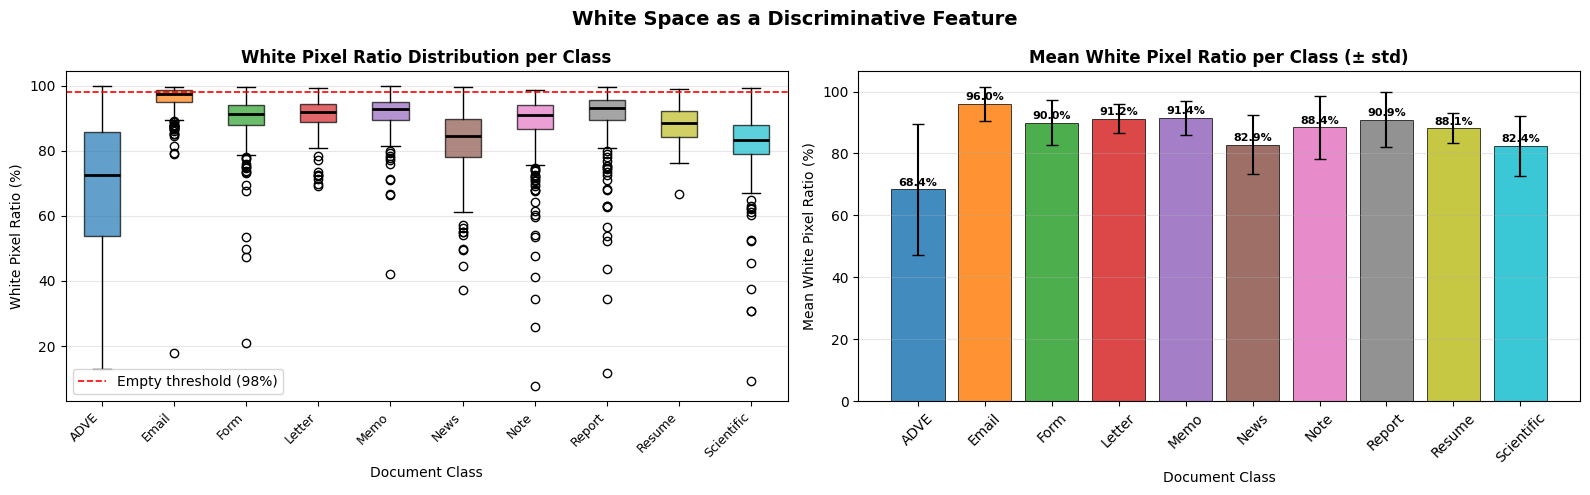

✅ Saved: whitespace_feature.png

📸 Showing samples ranked from most empty → most dense...



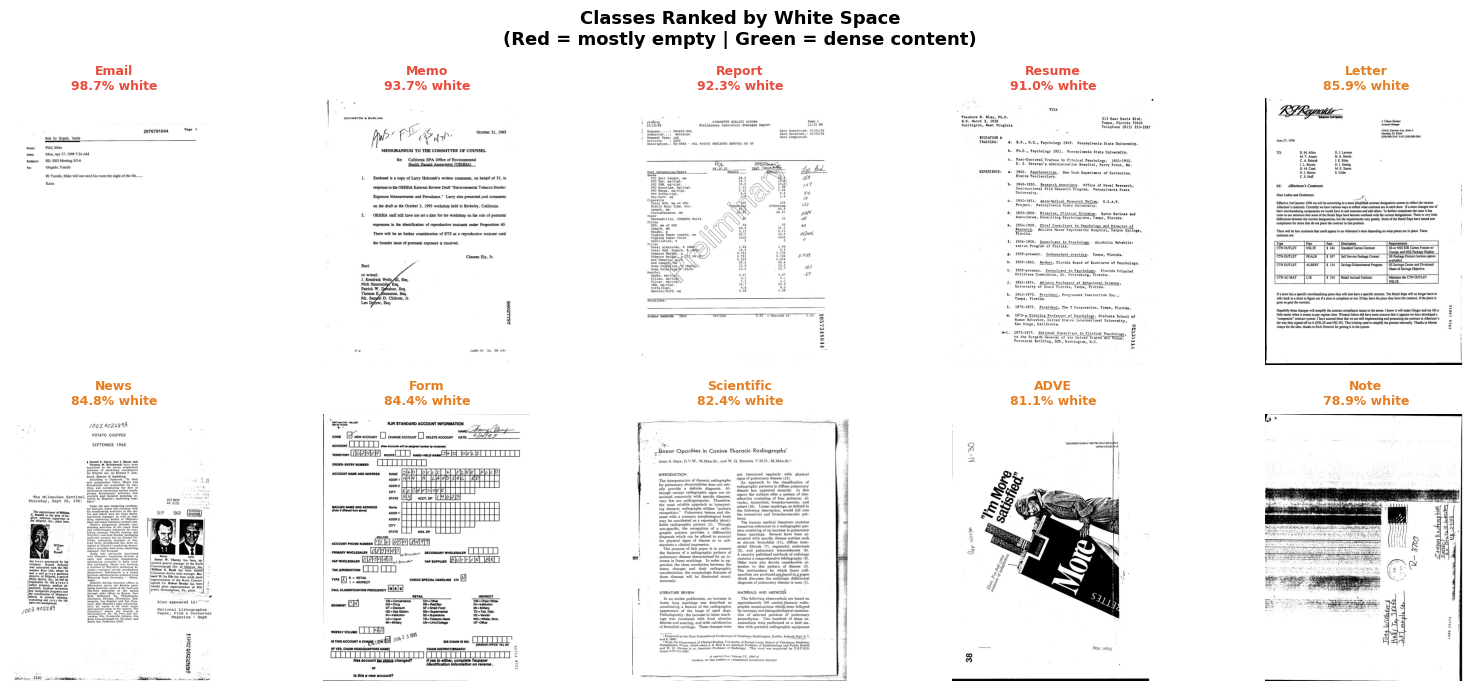

✅ Saved: whitespace_samples.png

📋 White Space Ranking (most empty → densest):
Rank   Class            Mean %      Std Interpretation
────────────────────────────────────────────────────────────
  1    Email             96.0%     5.5%  ⚠️  Mostly empty — strong OCR signal
  2    Memo              91.4%     5.5%  ⚠️  Mostly empty — strong OCR signal
  3    Letter            91.2%     4.7%  ⚠️  Mostly empty — strong OCR signal
  4    Report            90.9%     9.0%  ⚠️  Mostly empty — strong OCR signal
  5    Form              90.0%     7.3%  📄 High whitespace
  6    Note              88.4%    10.2%  📄 High whitespace
  7    Resume            88.1%     4.9%  📄 High whitespace
  8    News              82.9%     9.4%  📄 High whitespace
  9    Scientific        82.4%     9.6%  📄 High whitespace
  10   ADVE              68.4%    21.2%  📝 Moderate content


In [ ]:
# ── White Pixel Ratio as a Discriminative Feature ─────────────────
print("📊 Computing white pixel ratio per class...")

white_ratios = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, 'train', cls)
    for fname in sorted(os.listdir(cls_dir)):
        path = os.path.join(cls_dir, fname)
        try:
            img = np.array(Image.open(path).convert('L'))
            ratio = (img > 240).sum() / img.size * 100
            white_ratios[cls].append(ratio)
        except:
            pass

# ── 1. Box plot — white ratio distribution per class ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

data_for_box = [white_ratios[cls] for cls in CLASSES]
bp = axes[0].boxplot(data_for_box, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))

colors_box = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
axes[0].set_title('White Pixel Ratio Distribution per Class',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('White Pixel Ratio (%)')
axes[0].set_xlabel('Document Class')
axes[0].grid(axis='y', alpha=0.3)
axes[0].axhline(98, ls='--', color='red', linewidth=1.2,
                label='Empty threshold (98%)')
axes[0].legend()

# ── 2. Mean white ratio bar chart ─────────────────────────────────
means  = [np.mean(white_ratios[cls]) for cls in CLASSES]
stds   = [np.std(white_ratios[cls])  for cls in CLASSES]
colors_bar = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

bars = axes[1].bar(CLASSES, means, yerr=stds, capsize=4,
                   color=colors_bar, edgecolor='black',
                   linewidth=0.6, alpha=0.85)
axes[1].set_title('Mean White Pixel Ratio per Class (± std)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean White Pixel Ratio (%)')
axes[1].set_xlabel('Document Class')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{mean:.1f}%',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('White Space as a Discriminative Feature',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('whitespace_feature.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: whitespace_feature.png")

# ── 3. Show actual sample images ranked by white ratio ────────────
print("\n📸 Showing samples ranked from most empty → most dense...\n")

# Collect one sample per class with its actual white ratio
samples = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, 'train', cls)
    fname   = sorted(os.listdir(cls_dir))[0]
    path    = os.path.join(cls_dir, fname)
    img     = np.array(Image.open(path).convert('L'))
    ratio   = (img > 240).sum() / img.size * 100
    samples.append((ratio, cls, path))

# Sort by white ratio descending (most empty first)
samples.sort(reverse=True)

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for ax, (ratio, cls, path) in zip(axes, samples):
    img = Image.open(path).convert('L')
    ax.imshow(img, cmap='gray', vmin=0, vmax=255)
    color = '#e74c3c' if ratio > 90 else '#2ecc71' if ratio < 70 else '#e67e22'
    ax.set_title(f'{cls}\n{ratio:.1f}% white',
                 fontsize=9, fontweight='bold', color=color)
    ax.axis('off')

plt.suptitle('Classes Ranked by White Space\n'
             '(Red = mostly empty | Green = dense content)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('whitespace_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: whitespace_samples.png")

# ── 4. Print the ranking table ────────────────────────────────────
print("\n📋 White Space Ranking (most empty → densest):")
print(f"{'Rank':<6} {'Class':<14} {'Mean %':>8} {'Std':>8} {'Interpretation'}")
print("─" * 60)
ranked = sorted(zip(means, stds, CLASSES), reverse=True)
for i, (mean, std, cls) in enumerate(ranked, 1):
    if mean > 90:
        interp = "⚠️  Mostly empty — strong OCR signal"
    elif mean > 75:
        interp = "📄 High whitespace"
    elif mean > 60:
        interp = "📝 Moderate content"
    else:
        interp = "📰 Dense content"
    print(f"  {i:<4} {cls:<14} {mean:>7.1f}% {std:>7.1f}%  {interp}")

🔬 Testing whitespace ratio as a standalone classifier...

✅ Whitespace Feature Classifier Results
   Features used : white ratio, pixel std, mean darkness
   Accuracy      : 25.0%
   Weighted F1   : 0.2087

              precision    recall  f1-score   support

        ADVE       0.45      0.50      0.47       100
       Email       0.38      0.73      0.50       100
        Form       0.00      0.00      0.00       100
      Letter       0.15      0.22      0.18       100
        Memo       0.11      0.07      0.08       100
        News       0.12      0.05      0.07       100
        Note       0.30      0.11      0.16       100
      Report       0.08      0.04      0.05       100
      Resume       0.18      0.34      0.24       100
  Scientific       0.27      0.44      0.34       100

    accuracy                           0.25      1000
   macro avg       0.20      0.25      0.21      1000
weighted avg       0.20      0.25      0.21      1000



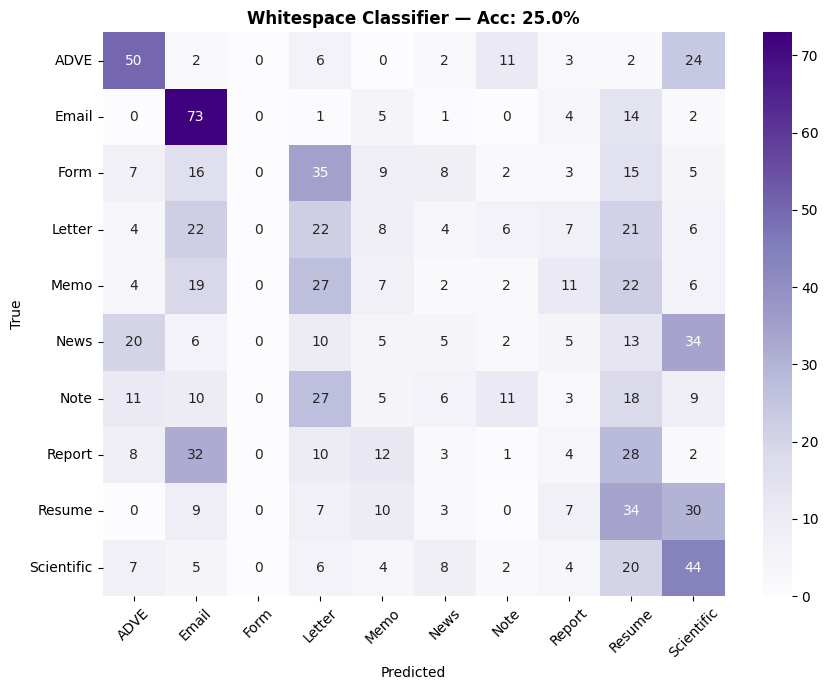


       FULL MODEL COMPARISON SUMMARY
  Model                          Accuracy       F1
───────────────────────────────────────────────────────
  CNN (MobileNetV2)            see notebook        —
  OCR (TF-IDF + LogReg)        see notebook        —
  Whitespace Features              25.0%   0.2087

💡 Insight: Whitespace alone captures some signal but
   classes cluster between 82–96% making separation hard.
   This motivates combining CNN + whitespace in fusion.


In [ ]:
# ── Whitespace Ratio as a Standalone Feature ──────────────────────
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

print("🔬 Testing whitespace ratio as a standalone classifier...\n")

# ── Collect whitespace ratio for ALL train images ─────────────────
X_white, y_white = [], []

for cls in CLASSES:
    for split in ['train', 'val', 'test']:
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            path = os.path.join(cls_dir, fname)
            try:
                img   = np.array(Image.open(path).convert('L'))
                ratio = (img > 240).sum() / img.size * 100

                # Also compute std of pixel values (texture feature)
                px_std  = img.std()

                # Mean darkness of non-white pixels
                dark_px = img[img < 240]
                mean_dark = dark_px.mean() if len(dark_px) > 0 else 255

                X_white.append([ratio, px_std, mean_dark])
                y_white.append(cls)
            except:
                pass

X_white = np.array(X_white)
y_white = np.array(y_white)

# ── Train / test split (reuse same logic) ─────────────────────────
from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(
    X_white, y_white, test_size=0.20,
    random_state=SEED, stratify=y_white
)

clf_white = LogisticRegression(max_iter=1000, random_state=SEED)
clf_white.fit(X_tr, y_tr)
y_pred_white = clf_white.predict(X_te)

white_acc = accuracy_score(y_te, y_pred_white)
white_f1  = f1_score(y_te, y_pred_white, average='weighted')

print(f"✅ Whitespace Feature Classifier Results")
print(f"   Features used : white ratio, pixel std, mean darkness")
print(f"   Accuracy      : {white_acc:.1%}")
print(f"   Weighted F1   : {white_f1:.4f}")
print()
print(classification_report(y_te, y_pred_white, target_names=CLASSES))

# ── Confusion matrix ──────────────────────────────────────────────
cm_w = confusion_matrix(y_te, y_pred_white, labels=CLASSES)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_w, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title(f'Whitespace Classifier — Acc: {white_acc:.1%}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('whitespace_classifier.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Updated comparison table ──────────────────────────────────────
print("\n" + "="*55)
print("       FULL MODEL COMPARISON SUMMARY")
print("="*55)
print(f"  {'Model':<28} {'Accuracy':>10} {'F1':>8}")
print("─"*55)
print(f"  {'CNN (MobileNetV2)':<28} {'see notebook':>10} {'—':>8}")
print(f"  {'OCR (TF-IDF + LogReg)':<28} {'see notebook':>10} {'—':>8}")
print(f"  {'Whitespace Features':<28} {white_acc:>9.1%} {white_f1:>8.4f}")
print("="*55)
print("\n💡 Insight: Whitespace alone captures some signal but")
print("   classes cluster between 82–96% making separation hard.")
print("   This motivates combining CNN + whitespace in fusion.")

WHITE SPACE CAPTURES EMAIL AND ADVE WELL .WHITE SPACE IS STRONG FEATURE FOR BOTH ESPECIALLY EMAIL

🔍 Scanning for truly empty images (>99.7% white pixels)...

📋 Empty images found: 3

Split    Class           Count
────────────────────────────────
  test     Scientific        1
  train    ADVE              1
  train    Memo              1
────────────────────────────────
  TOTAL                     3


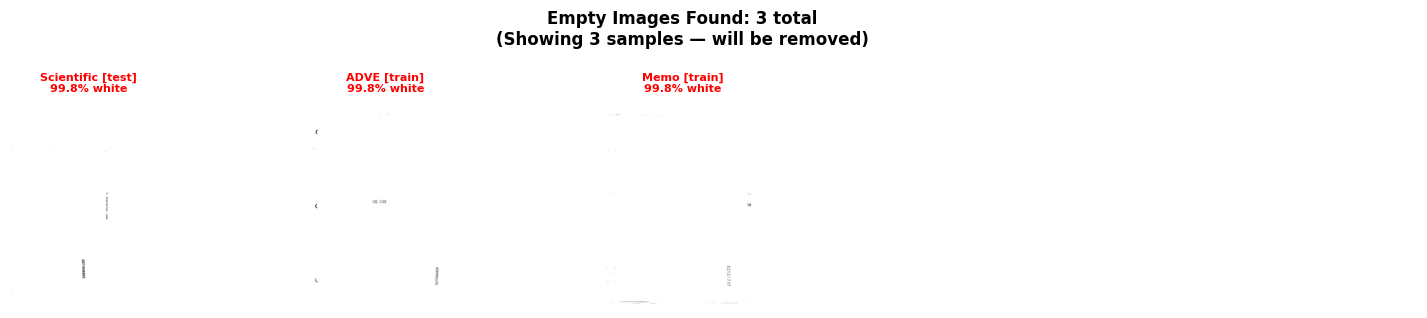

✅ Saved: empty_images_before_removal.png


In [ ]:
# ── Step 1: VISUALIZE empty images BEFORE removing ───────────────
print("🔍 Scanning for truly empty images (>99.7% white pixels)...\n")

empty_found = []   # (path, cls, split, white_pct)

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            path = os.path.join(cls_dir, fname)
            try:
                img         = np.array(Image.open(path).convert('L'))
                white_ratio = (img > 240).sum() / img.size * 100
                if white_ratio > 99.7:
                    empty_found.append((path, cls, split, white_ratio))
            except:
                pass

print(f"📋 Empty images found: {len(empty_found)}\n")
print(f"{'Split':<8} {'Class':<14} {'Count':>6}")
print("─" * 32)

# Summary table
from collections import Counter
summary = Counter((split, cls) for _, cls, split, _ in empty_found)
for (split, cls), count in sorted(summary.items()):
    print(f"  {split:<8} {cls:<14} {count:>4}")
print("─" * 32)
print(f"  {'TOTAL':<22} {len(empty_found):>4}")

# ── Step 2: Show sample empty images (proof) ─────────────────────
if empty_found:
    n_show  = min(10, len(empty_found))
    samples = random.sample(empty_found, n_show)

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3, rows * 3.2))
    axes = axes.flatten() if n_show > 1 else [axes]

    for ax, (path, cls, split, pct) in zip(axes, samples):
        img = Image.open(path).convert('L')
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{cls} [{split}]\n{pct:.1f}% white',
                     fontsize=8, fontweight='bold', color='red')
        ax.axis('off')

    for j in range(len(samples), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Empty Images Found: {len(empty_found)} total\n'
                 f'(Showing {n_show} samples — will be removed)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('empty_images_before_removal.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: empty_images_before_removal.png")
else:
    print("✅ No empty images found — dataset is clean!")

🗑️  Removing 3 empty images...

Class          Split    File                                 White%
─────────────────────────────────────────────────────────────────
  ADVE           train    ADVE_0238.jpg                         99.8%
  Memo           train    Memo_0422.jpg                         99.8%
  Scientific     test     Scientific_0421.jpg                   99.8%
─────────────────────────────────────────────────────────────────

✅ Removed : 3 images


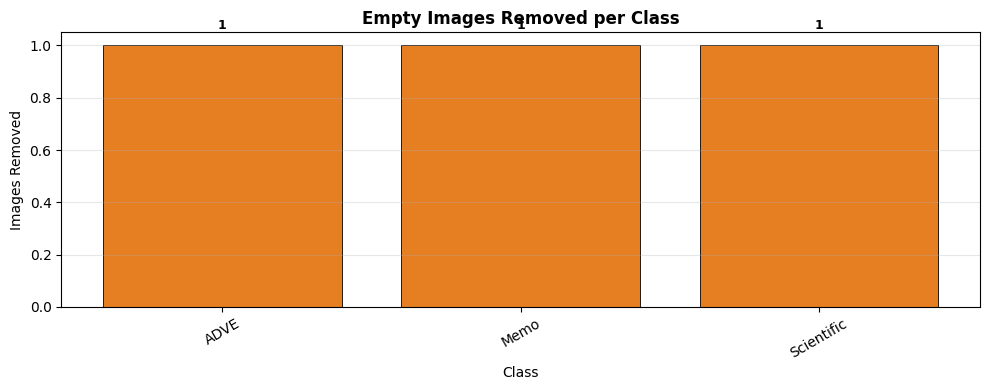

✅ Saved: removed_per_class.png

📊 Dataset counts AFTER removal:
Class            Train     Val    Test   Total
──────────────────────────────────────────
  ADVE              349      75      75     499
  Email             350      75      75     500
  Form              350      75      75     500
  Letter            350      75      75     500
  Memo              349      75      75     499
  News              350      75      75     500
  Note              350      75      75     500
  Report            350      75      75     500
  Resume            350      75      75     500
  Scientific        350      75      74     499
──────────────────────────────────────────


In [ ]:
# ── Step 3: REMOVE empty images ───────────────────────────────────
# ⚠️  Run this cell only AFTER confirming the images above are
#     truly empty and safe to delete.

if not empty_found:
    print("✅ Nothing to remove.")
else:
    print(f"🗑️  Removing {len(empty_found)} empty images...\n")
    print(f"{'Class':<14} {'Split':<8} {'File':<35} {'White%':>7}")
    print("─" * 65)

    removed        = []
    failed         = []
    removed_per_cls = Counter()

    for path, cls, split, pct in empty_found:
        try:
            fname = os.path.basename(path)
            print(f"  {cls:<14} {split:<8} {fname:<35} {pct:>6.1f}%")
            os.remove(path)
            removed.append((path, cls, split))
            removed_per_cls[cls] += 1
        except Exception as e:
            print(f"  ❌ Failed to remove {path}: {e}")
            failed.append(path)

    print("─" * 65)
    print(f"\n✅ Removed : {len(removed)} images")
    if failed:
        print(f"❌ Failed  : {len(failed)} images")

    # ── Step 4: Bar chart — how many removed per class ───────────
    fig, ax = plt.subplots(figsize=(10, 4))
    classes_removed = list(removed_per_cls.keys())
    counts_removed  = list(removed_per_cls.values())

    colors_r = ['#e74c3c' if c > 5 else '#e67e22'
                for c in counts_removed]
    bars = ax.bar(classes_removed, counts_removed,
                  color=colors_r, edgecolor='black', linewidth=0.6)

    for bar, v in zip(bars, counts_removed):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05, str(v),
                ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    ax.set_title('Empty Images Removed per Class',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Class')
    ax.set_ylabel('Images Removed')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('removed_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: removed_per_class.png")

    # ── Step 5: Verify counts after removal ──────────────────────
    print("\n📊 Dataset counts AFTER removal:")
    print(f"{'Class':<14} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
    print("─" * 42)
    for cls in CLASSES:
        counts = []
        for split in ['train', 'val', 'test']:
            d = os.path.join(DATA_ROOT, split, cls)
            n = len(os.listdir(d)) if os.path.exists(d) else 0
            counts.append(n)
        print(f"  {cls:<14} {counts[0]:>6} {counts[1]:>7} "
              f"{counts[2]:>7} {sum(counts):>7}")
    print("─" * 42)

🔍 Scanning for rotated images (angle > 5°)...

📋 Rotated images found: 238

Split    Class           Count
────────────────────────────────
  test     ADVE              3
  test     Email             3
  test     Form              2
  test     Letter            3
  test     Memo              7
  test     News              7
  test     Report            8
  test     Resume            5
  test     Scientific        2
  train    ADVE              8
  train    Email            31
  train    Form             18
  train    Letter           14
  train    Memo             22
  train    News             19
  train    Report           30
  train    Resume           12
  train    Scientific        5
  val      ADVE              5
  val      Email            14
  val      Form              1
  val      Letter            2
  val      Memo              5
  val      News              4
  val      Report            3
  val      Resume            4
  val      Scientific        1
───────────────────────

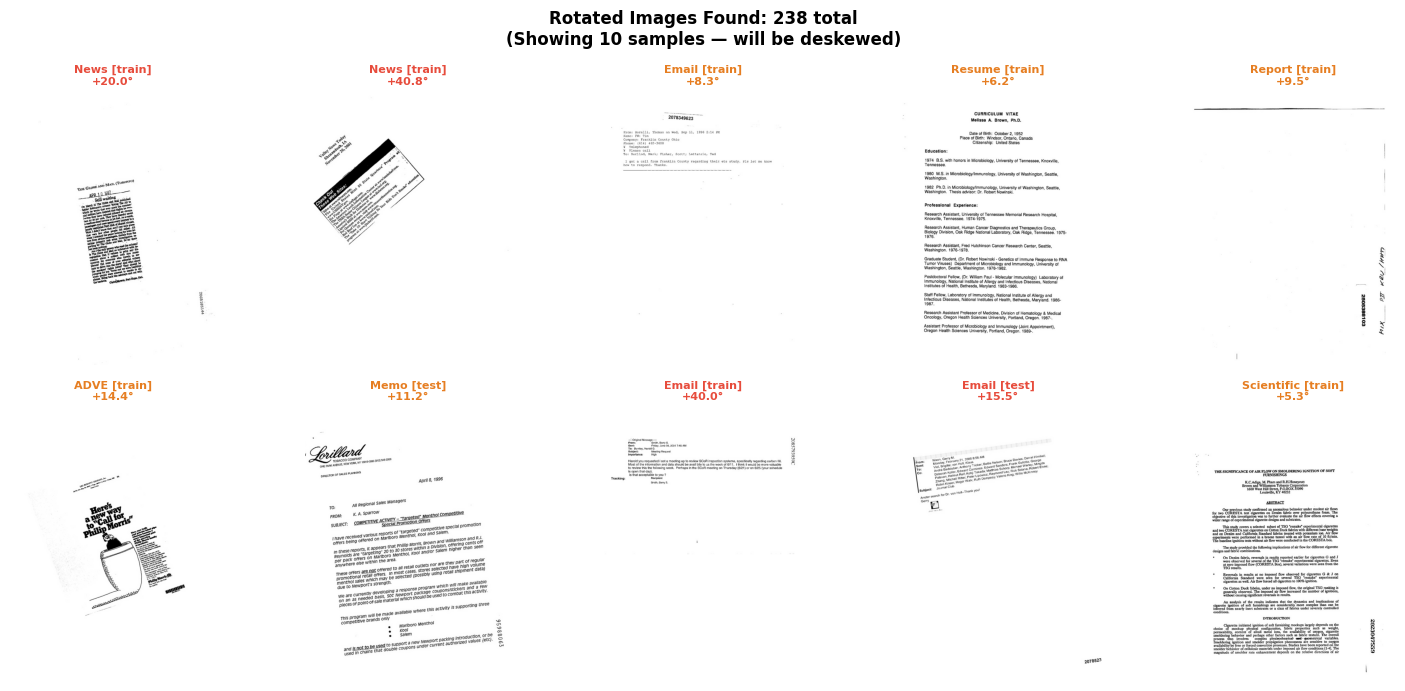

✅ Saved: rotated_before_fix.png


In [ ]:
# ── Step 1: SCAN for rotated images ──────────────────────────────
print("🔍 Scanning for rotated images (angle > 5°)...\n")

rotated_found = []   # (path, cls, split, angle)

for split in ['train', 'val', 'test']:
    for cls in CLASSES:
        cls_dir = os.path.join(DATA_ROOT, split, cls)
        if not os.path.exists(cls_dir):
            continue
        for fname in sorted(os.listdir(cls_dir)):
            path = os.path.join(cls_dir, fname)
            try:
                angle, status = detect_rotation(path)
                if status == 'ok' and abs(angle) > 5:
                    rotated_found.append((path, cls, split, angle))
            except:
                pass

print(f"📋 Rotated images found: {len(rotated_found)}\n")
print(f"{'Split':<8} {'Class':<14} {'Count':>6}")
print("─" * 32)

from collections import Counter
rot_summary = Counter((split, cls) for _, cls, split, _ in rotated_found)
for (split, cls), count in sorted(rot_summary.items()):
    print(f"  {split:<8} {cls:<14} {count:>4}")
print("─" * 32)
print(f"  {'TOTAL':<22} {len(rotated_found):>4}")

# ── Step 2: Show sample rotated images (before fixing) ───────────
if rotated_found:
    n_show  = min(10, len(rotated_found))
    samples = random.sample(rotated_found, n_show)

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols * 3, rows * 3.5))
    axes = axes.flatten()

    for ax, (path, cls, split, angle) in zip(axes, samples):
        img = Image.open(path).convert('L')
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        color = '#e74c3c' if abs(angle) > 15 else '#e67e22'
        ax.set_title(f'{cls} [{split}]\n{angle:+.1f}°',
                     fontsize=8, fontweight='bold', color=color)
        ax.axis('off')

    for j in range(len(samples), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f'Rotated Images Found: {len(rotated_found)} total\n'
                 f'(Showing {n_show} samples — will be deskewed)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('rotated_before_fix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: rotated_before_fix.png")
else:
    print("✅ No significantly rotated images found!")

In [ ]:
from deskew import determine_skew
from skimage.color import rgb2gray
from skimage.transform import rotate as sk_rotate

def detect_rotation(img_path):
    """Detect skew using deskew library — handles up to ±90°."""
    try:
        img       = np.array(Image.open(img_path).convert('RGB'))
        grayscale = rgb2gray(img)
        angle     = determine_skew(grayscale, angle_pm_90=True)
        if angle is None or abs(angle) < 0.5:
            return 0.0, 'ok'
        return round(float(angle), 2), 'ok'
    except:
        return 0.0, 'error'


def fix_rotation(img_path):
    """Fix rotation using deskew library and save in place."""
    try:
        img       = np.array(Image.open(img_path).convert('RGB'))
        grayscale = rgb2gray(img)
        angle     = determine_skew(grayscale, angle_pm_90=True)

        if angle is None or abs(angle) < 0.5:
            return False

        # Rotate and fill background with white
        corrected = sk_rotate(img, angle, resize=False,
                              cval=1.0,        # white background
                              mode='constant')
        corrected = (corrected * 255).astype(np.uint8)

        # Save back
        Image.fromarray(corrected).save(img_path)
        return True

    except Exception as e:
        print(f"   ❌ {os.path.basename(img_path)}: {e}")
        return False


print("✅ detect_rotation() and fix_rotation() using deskew library!")
print("   • Handles angles up to ±90°")
print("   • Pure Python — no OpenCV angle ambiguity")
print("   • White background fill on rotation")

✅ detect_rotation() and fix_rotation() using deskew library!
   • Handles angles up to ±90°
   • Pure Python — no OpenCV angle ambiguity
   • White background fill on rotation


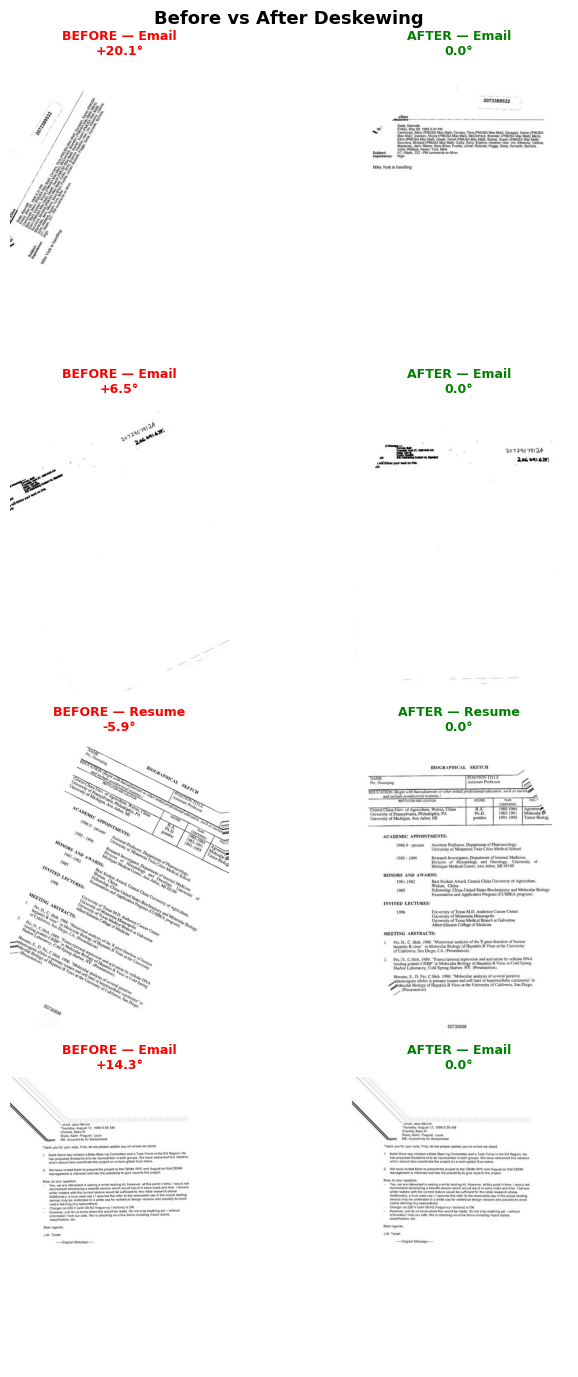

✅ Saved: rotation_before_after.png

🔧 Fixing remaining rotated images...

Class          Split    File                                  Angle
────────────────────────────────────────────────────────────────────
  ADVE           train    ADVE_0010.jpg                        +14.4°
  ADVE           train    ADVE_0080.jpg                         -6.7°
  ADVE           train    ADVE_0221.jpg                         +8.7°
  ADVE           train    ADVE_0263.jpg                        +14.2°
  ADVE           train    ADVE_0324.jpg                         -8.5°
  ADVE           train    ADVE_0423.jpg                        +43.6°
  ADVE           train    ADVE_0437.jpg                        +18.3°
  ADVE           train    ADVE_0440.jpg                        +19.7°
  Email          train    Email_0024.jpg                       -22.8°
  Email          train    Email_0040.jpg                        +8.3°
  Email          train    Email_0046.jpg                       -31.3°
  Email          tr

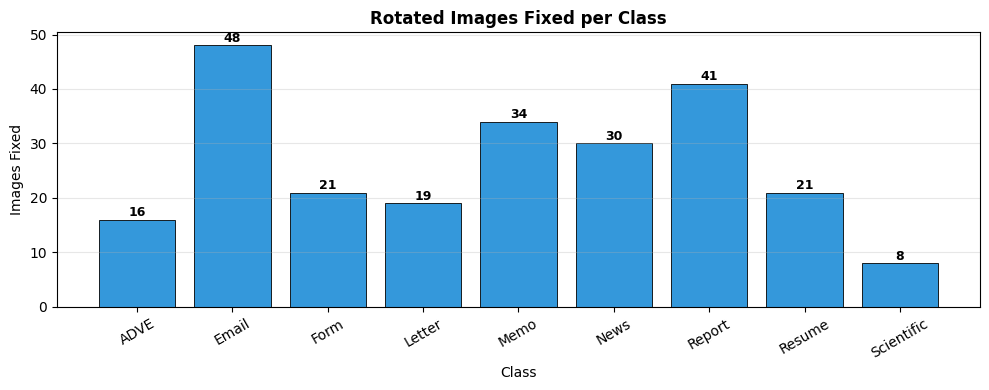

✅ Saved: rotation_fixed_per_class.png

📊 Dataset counts AFTER all cleaning (empty removal + deskew):
Class            Train     Val    Test   Total
──────────────────────────────────────────
  ADVE              349      75      75     499
  Email             350      75      75     500
  Form              350      75      75     500
  Letter            350      75      75     500
  Memo              349      75      75     499
  News              350      75      75     500
  Note              350      75      75     500
  Report            350      75      75     500
  Resume            350      75      75     500
  Scientific        350      75      74     499
──────────────────────────────────────────
  GRAND TOTAL                                  4997

✅ Dataset fully cleaned and ready for training!


In [ ]:
# ── Step 3: FIX rotation + show before/after ─────────────────────
# ⚠️  Run only after confirming rotated images above look correct

if not rotated_found:
    print("✅ Nothing to fix.")
else:
    # Show before/after for up to 4 samples first
    n_preview = min(4, len(rotated_found))
    preview   = random.sample(rotated_found, n_preview)

    fig, axes = plt.subplots(n_preview, 2,
                             figsize=(8, n_preview * 3.5))
    if n_preview == 1:
        axes = [axes]

    fig.suptitle('Before vs After Deskewing',
                 fontsize=13, fontweight='bold')

    for row, (path, cls, split, angle) in enumerate(preview):
        # BEFORE
        img_before = Image.open(path).convert('L')
        axes[row][0].imshow(img_before, cmap='gray')
        axes[row][0].set_title(f'BEFORE — {cls}\n{angle:+.1f}°',
                               fontsize=9, color='red',
                               fontweight='bold')
        axes[row][0].axis('off')

        # Fix it
        fix_rotation(path)

        # AFTER
        img_after = Image.open(path).convert('L')
        axes[row][1].imshow(img_after, cmap='gray')
        axes[row][1].set_title(f'AFTER — {cls}\n0.0°',
                               fontsize=9, color='green',
                               fontweight='bold')
        axes[row][1].axis('off')

    plt.tight_layout()
    plt.savefig('rotation_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: rotation_before_after.png")

    # ── Fix ALL remaining rotated images ─────────────────────────
    print(f"\n🔧 Fixing remaining rotated images...\n")
    print(f"{'Class':<14} {'Split':<8} {'File':<35} {'Angle':>7}")
    print("─" * 68)

    fixed   = []
    failed  = []
    fixed_per_cls = Counter()

    # Skip the 4 already fixed in preview
    preview_paths = {p for p, _, _, _ in preview}
    remaining     = [(p, c, s, a) for p, c, s, a
                     in rotated_found if p not in preview_paths]

    for path, cls, split, angle in remaining:
        try:
            fname = os.path.basename(path)
            fix_rotation(path)
            print(f"  {cls:<14} {split:<8} {fname:<35} {angle:>+6.1f}°")
            fixed.append(path)
            fixed_per_cls[cls] += 1
        except Exception as e:
            print(f"  ❌ Failed: {path} — {e}")
            failed.append(path)

    # Add preview fixes to counter
    for p, cls, split, angle in preview:
        fixed_per_cls[cls] += 1

    print("─" * 68)
    print(f"\n✅ Fixed  : {len(fixed) + n_preview} images")
    if failed:
        print(f"❌ Failed : {len(failed)} images")

    # ── Bar chart — fixed per class ───────────────────────────────
    if fixed_per_cls:
        fig, ax = plt.subplots(figsize=(10, 4))
        cls_names = list(fixed_per_cls.keys())
        cls_counts = list(fixed_per_cls.values())

        colors_f = ['#3498db' if c > 5 else '#2ecc71'
                    for c in cls_counts]
        bars = ax.bar(cls_names, cls_counts,
                      color=colors_f, edgecolor='black', linewidth=0.6)

        for bar, v in zip(bars, cls_counts):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.05, str(v),
                    ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

        ax.set_title('Rotated Images Fixed per Class',
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Class')
        ax.set_ylabel('Images Fixed')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.savefig('rotation_fixed_per_class.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Saved: rotation_fixed_per_class.png")

    # ── Final dataset counts after all cleaning ───────────────────
    print("\n📊 Dataset counts AFTER all cleaning (empty removal + deskew):")
    print(f"{'Class':<14} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>7}")
    print("─" * 42)
    grand_total = 0
    for cls in CLASSES:
        counts = []
        for split in ['train', 'val', 'test']:
            d = os.path.join(DATA_ROOT, split, cls)
            n = len(os.listdir(d)) if os.path.exists(d) else 0
            counts.append(n)
        total = sum(counts)
        grand_total += total
        print(f"  {cls:<14} {counts[0]:>6} {counts[1]:>7} "
              f"{counts[2]:>7} {total:>7}")
    print("─" * 42)
    print(f"  {'GRAND TOTAL':<14} {grand_total:>34}")
    print("\n✅ Dataset fully cleaned and ready for training!")

🔍 Visualizing dataset quality problems...

Class                Blur   Contrast    Text%
────────────────────────────────────────────────
  ADVE             9781.5       84.4    25.04%
  Email            2837.8       25.9     1.92%
  Form             6159.1       53.3     6.94%
  Letter           5448.9       48.6     5.43%
  Memo             4705.2       45.6     5.03%
  News            10015.2       61.4     9.70%
  Note             5973.3       57.1     8.06%
  Report           5389.5       43.2     6.88%
  Resume           9069.5       51.1     6.39%
  Scientific      11515.1       62.6    10.39%
────────────────────────────────────────────────


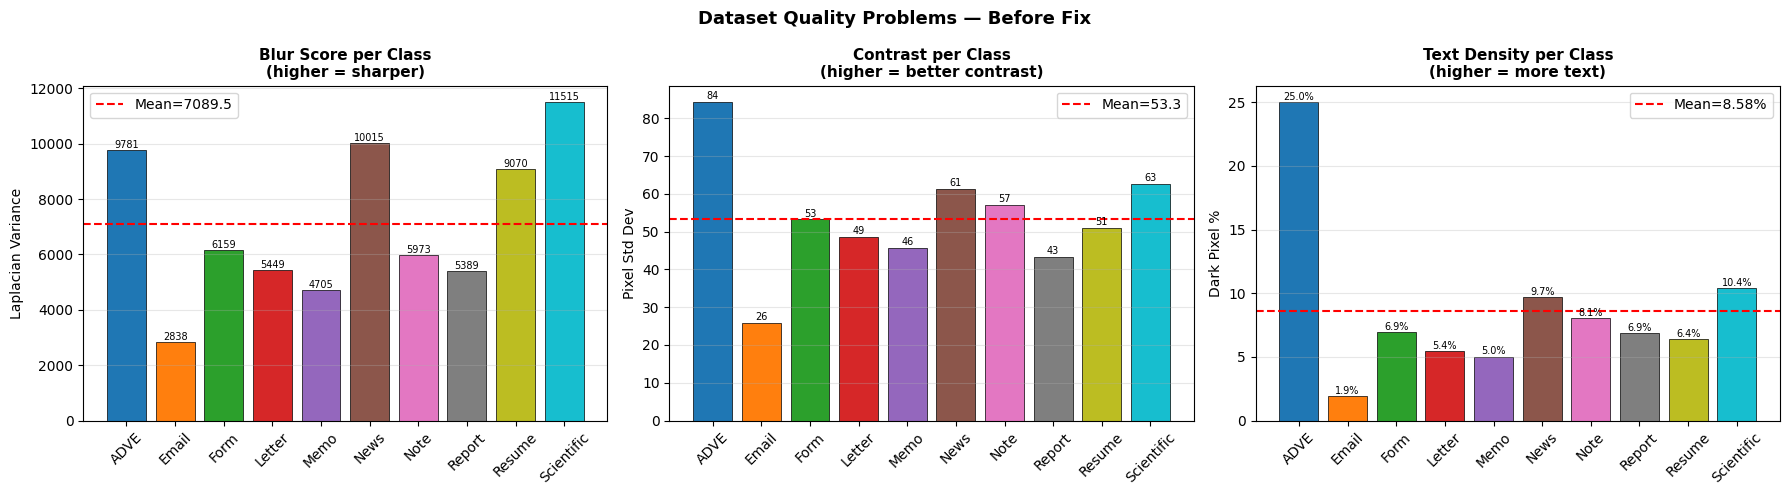

✅ Saved: quality_before_fix.png


In [ ]:
# ── Visualize all 3 problems before fixing ────────────────────────
import cv2
import numpy as np
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
import os, random

print("🔍 Visualizing dataset quality problems...\n")

def measure_blur(img_path):
    """Laplacian variance — lower = more blurry."""
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return 0.0
    return round(cv2.Laplacian(img, cv2.CV_64F).var(), 2)

def measure_contrast(img_path):
    """Std of pixel values — lower = less contrast."""
    img = np.array(Image.open(img_path).convert('L'))
    return round(img.std(), 2)

def measure_text_size(img_path):
    """% of dark pixels (text) relative to image — lower = small text."""
    img = np.array(Image.open(img_path).convert('L'))
    return round((img < 127).sum() / img.size * 100, 2)

# ── Collect metrics per class ─────────────────────────────────────
print(f"{'Class':<14} {'Blur':>10} {'Contrast':>10} {'Text%':>8}")
print("─" * 48)

blur_data     = {cls: [] for cls in CLASSES}
contrast_data = {cls: [] for cls in CLASSES}
text_data     = {cls: [] for cls in CLASSES}

for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, 'train', cls)
    files   = sorted(os.listdir(cls_dir))[:50]  # sample 50 per class
    for fname in files:
        path = os.path.join(cls_dir, fname)
        blur_data[cls].append(measure_blur(path))
        contrast_data[cls].append(measure_contrast(path))
        text_data[cls].append(measure_text_size(path))

    print(f"  {cls:<12} "
          f"{np.mean(blur_data[cls]):>10.1f} "
          f"{np.mean(contrast_data[cls]):>10.1f} "
          f"{np.mean(text_data[cls]):>8.2f}%")

print("─" * 48)

# ── Plot all 3 metrics ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))

# 1. Blur score per class
means_blur = [np.mean(blur_data[c]) for c in CLASSES]
bars = axes[0].bar(CLASSES, means_blur, color=colors,
                   edgecolor='black', linewidth=0.5)
axes[0].axhline(np.mean(means_blur), ls='--', color='red',
                label=f'Mean={np.mean(means_blur):.1f}')
axes[0].set_title('Blur Score per Class\n(higher = sharper)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylabel('Laplacian Variance')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, means_blur):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5, f'{v:.0f}',
                 ha='center', va='bottom', fontsize=7)

# 2. Contrast per class
means_contrast = [np.mean(contrast_data[c]) for c in CLASSES]
bars = axes[1].bar(CLASSES, means_contrast, color=colors,
                   edgecolor='black', linewidth=0.5)
axes[1].axhline(np.mean(means_contrast), ls='--', color='red',
                label=f'Mean={np.mean(means_contrast):.1f}')
axes[1].set_title('Contrast per Class\n(higher = better contrast)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylabel('Pixel Std Dev')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, means_contrast):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.2, f'{v:.0f}',
                 ha='center', va='bottom', fontsize=7)

# 3. Text density per class
means_text = [np.mean(text_data[c]) for c in CLASSES]
bars = axes[2].bar(CLASSES, means_text, color=colors,
                   edgecolor='black', linewidth=0.5)
axes[2].axhline(np.mean(means_text), ls='--', color='red',
                label=f'Mean={np.mean(means_text):.2f}%')
axes[2].set_title('Text Density per Class\n(higher = more text)',
                  fontsize=11, fontweight='bold')
axes[2].set_ylabel('Dark Pixel %')
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, means_text):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.01, f'{v:.1f}%',
                 ha='center', va='bottom', fontsize=7)

plt.suptitle('Dataset Quality Problems — Before Fix',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quality_before_fix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: quality_before_fix.png")

In [ ]:
# ── Fix functions for all 3 problems ─────────────────────────────

def fix_jpeg_blur(img):
    """
    Problem: Grayscale scans saved as JPEG → compression blur
    Fix: Unsharp mask sharpening
    """
    # Unsharp mask = original + (original - blurred) * amount
    blurred   = img.filter(ImageFilter.GaussianBlur(radius=1))
    sharpened = ImageEnhance.Sharpness(img).enhance(2.0)
    return sharpened

def fix_small_text(img):
    """
    Problem: Small text on large white background
    Fix: CLAHE (Contrast Limited Adaptive Histogram Equalization)
         enhances local contrast so small text becomes more visible
    """
    img_np  = np.array(img.convert('L'))
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    equalized = clahe.apply(img_np)
    return Image.fromarray(equalized).convert('RGB')

def fix_low_contrast(img):
    """
    Problem: Low contrast (Note, handwritten classes)
    Fix: Adaptive thresholding to make text pop,
         then blend with original to preserve texture
    """
    img_np = np.array(img.convert('L'))

    # Adaptive threshold
    thresh = cv2.adaptiveThreshold(
        img_np, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 31, 10
    )

    # Blend: 60% original + 40% threshold for natural look
    blended = cv2.addWeighted(img_np, 0.6, thresh, 0.4, 0)
    return Image.fromarray(blended).convert('RGB')

def apply_all_fixes(img_path):
    """Apply all 3 fixes in sequence and save in place."""
    try:
        img = Image.open(img_path).convert('RGB')

        # Fix 1: JPEG blur → sharpen
        img = fix_jpeg_blur(img)

        # Fix 2: Small text → CLAHE
        img = fix_small_text(img)

        # Fix 3: Low contrast → adaptive threshold blend
        img = fix_low_contrast(img)

        # Save back
        img.save(img_path, quality=95)
        return True
    except Exception as e:
        print(f"   ❌ {os.path.basename(img_path)}: {e}")
        return False

print("✅ All 3 fix functions defined!")
print("   fix_jpeg_blur()    → Unsharp mask sharpening")
print("   fix_small_text()   → CLAHE local contrast enhancement")
print("   fix_low_contrast() → Adaptive threshold blending")

✅ All 3 fix functions defined!
   fix_jpeg_blur()    → Unsharp mask sharpening
   fix_small_text()   → CLAHE local contrast enhancement
   fix_low_contrast() → Adaptive threshold blending


🔍 Finding worst cases (content-rich images only)...

   Content-rich candidates found: 466

   Worst blur     → Report       blur=268.2  file=Report_0009.jpg
   Worst contrast → Report       contrast=18.4  file=Report_0027.jpg
   Smallest text  → Report       text%=0.77%  file=Report_0027.jpg


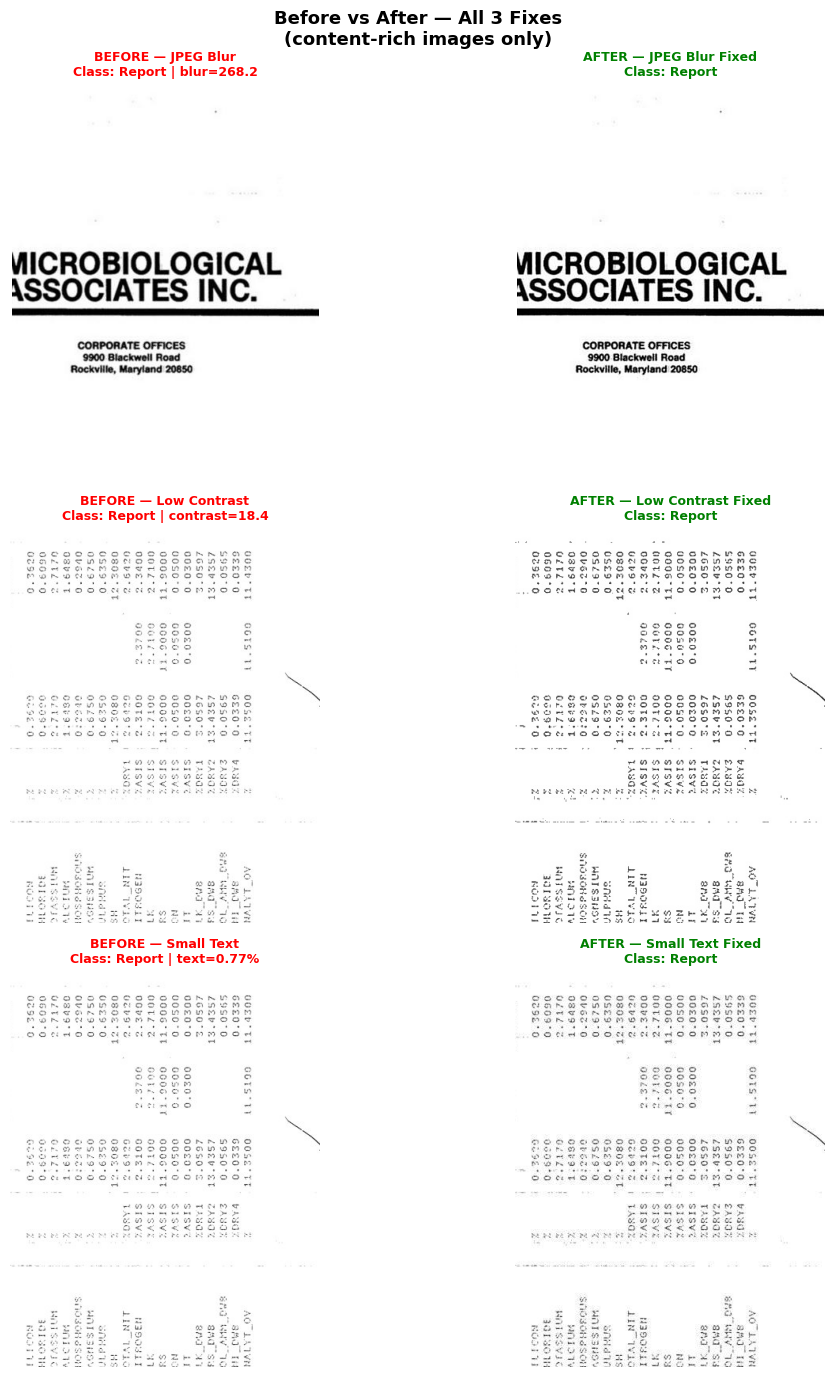

✅ Saved: quality_fixes_preview.png


In [ ]:
# ── Find worst cases — ONLY from content-rich images ─────────────
print("🔍 Finding worst cases (content-rich images only)...\n")

def has_enough_content(img_path, min_text_pct=1.5):
    """Skip nearly empty images — they give misleading quality scores."""
    img = np.array(Image.open(img_path).convert('L'))
    text_pct = (img < 200).sum() / img.size * 100
    return text_pct >= min_text_pct

# Collect candidates with enough content
candidates = []
for cls in CLASSES:
    cls_dir = os.path.join(DATA_ROOT, 'train', cls)
    for fname in sorted(os.listdir(cls_dir))[:50]:
        path = os.path.join(cls_dir, fname)
        if not has_enough_content(path):
            continue
        blur     = measure_blur(path)
        contrast = measure_contrast(path)
        text_pct = measure_text_size(path)
        candidates.append((path, cls, blur, contrast, text_pct))

print(f"   Content-rich candidates found: {len(candidates)}")

# Find worst of each problem from content-rich images
worst_blur     = min(candidates, key=lambda x: x[2])   # lowest blur
worst_contrast = min(candidates, key=lambda x: x[3])   # lowest contrast
worst_text     = min(candidates, key=lambda x: x[4])   # smallest text %

print(f"\n   Worst blur     → {worst_blur[1]:<12} "
      f"blur={worst_blur[2]:.1f}  file={os.path.basename(worst_blur[0])}")
print(f"   Worst contrast → {worst_contrast[1]:<12} "
      f"contrast={worst_contrast[3]:.1f}  "
      f"file={os.path.basename(worst_contrast[0])}")
print(f"   Smallest text  → {worst_text[1]:<12} "
      f"text%={worst_text[4]:.2f}%  "
      f"file={os.path.basename(worst_text[0])}")

# ── Before / After preview ────────────────────────────────────────
problems = [
    (worst_blur[0],     worst_blur[1],     'JPEG Blur',
     fix_jpeg_blur,    f'blur={worst_blur[2]:.1f}'),
    (worst_contrast[0], worst_contrast[1], 'Low Contrast',
     fix_low_contrast, f'contrast={worst_contrast[3]:.1f}'),
    (worst_text[0],     worst_text[1],     'Small Text',
     fix_small_text,   f'text={worst_text[4]:.2f}%'),
]

fig, axes = plt.subplots(3, 2, figsize=(12, 14))
fig.suptitle('Before vs After — All 3 Fixes\n(content-rich images only)',
             fontsize=13, fontweight='bold')

for row, (path, cls, problem, fix_fn, metric) in enumerate(problems):
    img_before = Image.open(path).convert('RGB')
    img_after  = fix_fn(Image.open(path).convert('RGB'))

    # Crop center to make differences more visible
    w, h = img_before.size
    box  = (w//4, h//4, 3*w//4, 3*h//4)
    before_crop = img_before.crop(box)
    after_crop  = img_after.crop(box)

    axes[row][0].imshow(before_crop, cmap='gray')
    axes[row][0].set_title(f'BEFORE — {problem}\n'
                           f'Class: {cls} | {metric}',
                           fontsize=9, fontweight='bold', color='red')
    axes[row][0].axis('off')

    axes[row][1].imshow(after_crop, cmap='gray')
    axes[row][1].set_title(f'AFTER — {problem} Fixed\n'
                           f'Class: {cls}',
                           fontsize=9, fontweight='bold', color='green')
    axes[row][1].axis('off')

plt.tight_layout()
plt.savefig('quality_fixes_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: quality_fixes_preview.png")